
# LeRobot PushT 数据结构与代码功能：逐单元学习

这份 Notebook 用于逐步理解：

1. `LeRobotDatasetMetadata` 是什么；
2. `LeRobotDataset` 是什么；
3. `dataset[0]` 和 `sample["action"]` 分别表示什么；
4. 一个 episode、frame、sample、transition 如何对应；
5. 图像、状态、动作、索引和任务字段的数据类型与 shape；
6. 如何从相邻 frame 构造状态转移；
7. 如何从逐帧 action 构造 ACT 所需的 action chunk。

建议按顺序逐个运行单元格，不要一次性“全部运行”。每运行一个代码单元，就观察输出并阅读紧随其后的解释。



## 0. 运行环境

先在 PowerShell 中激活环境：

```powershell
conda activate lerobot-win
```

在 VS Code 中打开本 Notebook，并确认右上角内核使用：

```text
D:\Desktop\robot\envs\lerobot-win\python.exe
```

若 VS Code 找不到 Notebook 内核，可在该环境中安装：

```powershell
python -m pip install jupyter ipykernel
python -m ipykernel install --user --name lerobot-win --display-name "Python (lerobot-win)"
```


In [1]:

# 检查当前 Notebook 实际使用的 Python 与主要软件版本
import sys
import site

import torch
import lerobot

print("Python 可执行文件：", sys.executable)
print("Python 版本：", sys.version)
print("用户 site-packages 是否启用：", site.ENABLE_USER_SITE)
print("PyTorch 版本：", torch.__version__)
print("CUDA 可用：", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU：", torch.cuda.get_device_name(0))

print("LeRobot 模块位置：", lerobot.__file__)


Python 可执行文件： d:\Desktop\robot\envs\lerobot-win\python.exe
Python 版本： 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:36:12) [MSC v.1944 64 bit (AMD64)]
用户 site-packages 是否启用： False
PyTorch 版本： 2.11.0+cu128
CUDA 可用： True
GPU： NVIDIA GeForce RTX 4060 Laptop GPU
LeRobot 模块位置： d:\Desktop\robot\envs\lerobot-win\Lib\site-packages\lerobot\__init__.py



### 观察重点

- `sys.executable` 应指向 D 盘的 `lerobot-win` 环境。
- `site.ENABLE_USER_SITE` 应为 `False`，避免用户级 Python 包污染 Conda 环境。
- 数据集读取阶段通常在 CPU 上完成；训练 batch 才会送入 GPU。


## 1. 导入数据集类并设置数据集 ID

In [1]:

from pprint import pprint
from typing import Any

import torch
import matplotlib.pyplot as plt

from lerobot.datasets import LeRobotDataset, LeRobotDatasetMetadata

REPO_ID = "lerobot/pusht"

print("当前数据集：", REPO_ID)


当前数据集： lerobot/pusht



这里导入了两个核心类：

- `LeRobotDatasetMetadata`：读取数据集的说明信息与结构信息；
- `LeRobotDataset`：真正读取 frame、图像、状态和动作。

`REPO_ID = "lerobot/pusht"` 是数据集的逻辑标识。程序会优先查找本地 Hugging Face 缓存，缺失文件时才联网补齐。


## 2. 创建 `LeRobotDatasetMetadata` 对象

In [2]:

metadata = LeRobotDatasetMetadata(REPO_ID)

print("对象类型：", type(metadata))
print("对象所属类：", metadata.__class__)


Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 611.46it/s]

对象类型： <class 'lerobot.datasets.dataset_metadata.LeRobotDatasetMetadata'>
对象所属类： <class 'lerobot.datasets.dataset_metadata.LeRobotDatasetMetadata'>



这行代码：

```python
metadata = LeRobotDatasetMetadata(REPO_ID)
```

可以拆成：

- `LeRobotDatasetMetadata`：类；
- `metadata`：根据类创建出的对象或实例；
- `metadata.total_episodes`：读取对象的属性；
- `metadata.get_data_file_path(...)`：调用对象的方法。

一般来说：

```text
对象.属性
对象.方法(...)
```

属性通常用于读取信息，方法通常用于执行操作。


## 3. 读取常用 metadata 属性

In [3]:

print("repo_id：", metadata.repo_id)
print("root：", metadata.root)
print("revision：", metadata.revision)
print("总 episode 数：", metadata.total_episodes)
print("总 frame 数：", metadata.total_frames)
print("总任务数：", metadata.total_tasks)
print("FPS：", metadata.fps)
print("机器人类型：", metadata.robot_type)
print("相机字段：", metadata.camera_keys)
print("图像字段：", metadata.image_keys)
print("视频字段：", metadata.video_keys)


repo_id： lerobot/pusht
root： D:\Desktop\robot\datasets\lerobot\hub\datasets--lerobot--pusht\snapshots\b1c3ecbae7f244acc039a3dbc255a00dad1372b9
revision： v3.0
总 episode 数： 206
总 frame 数： 25650
总任务数： 1
FPS： 10
机器人类型： unknown
相机字段： ['observation.image']
图像字段： []
视频字段： ['observation.image']



### 属性的含义

- `total_episodes`：完整任务回合数量；
- `total_frames`：所有 episode 的 frame 总数；
- `fps`：每秒采样多少帧；
- `camera_keys`：可作为相机观测的字段；
- `video_keys`：底层以视频形式存储的字段；
- `robot_type`：数据集声明的机器人类型，PushT 中可能为 `unknown`。

这些属性用于回答“这个数据集整体是什么样的”，还没有读取某个具体 frame。


## 4. 查看任务表与字段定义

In [4]:

print("任务表：")
display(metadata.tasks)

print("\n字段定义：")
pprint(metadata.features)


任务表：


,task_index
task,
Push the T-shaped block onto the T-shaped target.,0



字段定义：
{'action': {'dtype': 'float32',
            'fps': 10.0,
            'names': {'motors': ['motor_0', 'motor_1']},
            'shape': (2,)},
 'episode_index': {'dtype': 'int64', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'frame_index': {'dtype': 'int64', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'index': {'dtype': 'int64', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'next.done': {'dtype': 'bool', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'next.reward': {'dtype': 'float32', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'next.success': {'dtype': 'bool', 'fps': 10.0, 'names': None, 'shape': (1,)},
 'observation.image': {'dtype': 'video',
                       'names': ['height', 'width', 'channel'],
                       'shape': (96, 96, 3),
                       'video_info': {'has_audio': False,
                                      'video.codec': 'av1',
                                      'video.fps': 10.0,
                                      'video.is_depth_map


`metadata.features` 是一个字典。每个键代表一个数据字段，例如：

```python
metadata.features["action"]
metadata.features["observation.image"]
```

每个字段通常包含：

- `dtype`：数据类型；
- `shape`：单条数据的形状；
- `names`：各维度含义；
- `fps`：采样频率；
- `video_info`：视频编码信息。

注意：这里的 `metadata.features["action"]` 使用方括号，因为 `features` 是字典，而不是一个具有 `.action` 属性的对象。


In [5]:

action_feature = metadata.features["action"]
image_feature = metadata.features["observation.image"]
state_feature = metadata.features["observation.state"]

print("action 字段：")
pprint(action_feature)

print("\nobservation.image 字段：")
pprint(image_feature)

print("\nobservation.state 字段：")
pprint(state_feature)


action 字段：
{'dtype': 'float32',
 'fps': 10.0,
 'names': {'motors': ['motor_0', 'motor_1']},
 'shape': (2,)}

observation.image 字段：
{'dtype': 'video',
 'names': ['height', 'width', 'channel'],
 'shape': (96, 96, 3),
 'video_info': {'has_audio': False,
                'video.codec': 'av1',
                'video.fps': 10.0,
                'video.is_depth_map': False,
                'video.pix_fmt': 'yuv420p'}}

observation.state 字段：
{'dtype': 'float32',
 'fps': 10.0,
 'names': {'motors': ['motor_0', 'motor_1']},
 'shape': (2,)}


## 5. 查看数据集统计量 `metadata.stats`

In [6]:

print("统计量包含的字段：")
print(metadata.stats.keys())

print("\naction 统计量：")
pprint(metadata.stats.get("action"))

print("\nobservation.state 统计量：")
pprint(metadata.stats.get("observation.state"))


统计量包含的字段：
dict_keys(['index', 'next.success', 'observation.state', 'next.done', 'observation.image', 'timestamp', 'episode_index', 'frame_index', 'action', 'task_index', 'next.reward'])

action 统计量：
{'count': array([25650]),
 'max': array([511., 511.]),
 'mean': array([228.23964986, 293.98908412]),
 'min': array([12., 25.]),
 'std': array([101.59957463,  96.03928986])}

observation.state 统计量：
{'count': array([25650]),
 'max': array([496.1461792 , 510.95788574]),
 'mean': array([229.11103167, 293.31123679]),
 'min': array([13.45642376, 32.93829346]),
 'std': array([101.85470506,  96.48948719])}



统计量通常包含均值、标准差、最小值和最大值等信息。

训练策略模型时，常会对状态和动作做归一化，例如：

```text
原始坐标 0～512
        ↓
归一化
接近 -1～1 或均值为 0 的范围
```

归一化可以改善神经网络训练的数值稳定性。部署时，模型输出还需要反归一化回真实动作空间。


## 6. 创建只包含 episode 0 的 `LeRobotDataset`

In [7]:

dataset = LeRobotDataset(
    REPO_ID,
    episodes=[0],
)

print("对象类型：", type(dataset))
print("选择的 episode：", dataset.episodes)
print("当前 episode 数：", dataset.num_episodes)
print("当前 frame 数：", dataset.num_frames)
print("len(dataset)：", len(dataset))
print("FPS：", dataset.fps)


Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 724.72it/s]

对象类型： <class 'lerobot.datasets.lerobot_dataset.LeRobotDataset'>
选择的 episode： [0]
当前 episode 数： 1
当前 frame 数： 161
len(dataset)： 161
FPS： 10



这里的：

```python
episodes=[0]
```

表示只选择原始数据集中的第 0 个 episode。

因此当前 `dataset` 是一个“筛选后的数据集视图”，里面只包含 episode 0 的全部 frame。

`len(dataset)` 返回当前筛选范围中的 frame 数，不是 episode 数。


## 7. 理解 `sample = dataset[0]`

In [8]:

sample = dataset[0]

print("sample 的 Python 类型：", type(sample))
print("sample 包含的字段：")

for key in sample.keys():
    print(" -", key)


sample 的 Python 类型： <class 'dict'>
sample 包含的字段：
 - observation.image
 - observation.state
 - action
 - episode_index
 - frame_index
 - timestamp
 - next.reward
 - next.done
 - next.success
 - index
 - task_index
 - task



`dataset[0]` 的含义是：

> 读取当前 dataset 视图中的第 0 条 frame 样本。

它不是直接表示第 0 个 episode。episode 已经在创建 dataset 时通过 `episodes=[0]` 选定。

当前条件下：

```text
episodes=[0]
dataset[0]
```

恰好表示“episode 0 的第一帧”。

若改成：

```python
dataset = LeRobotDataset(REPO_ID, episodes=[5])
sample = dataset[0]
```

那么 `sample` 是“episode 5 的第一帧”。


## 8. 查看 sample 中每个字段的类型与 shape

In [9]:

def describe_value(name: str, value: Any) -> None:
    print(f"\n{name}")
    print("  Python 类型：", type(value).__name__)

    if isinstance(value, torch.Tensor):
        print("  shape：", tuple(value.shape))
        print("  dtype：", value.dtype)
        print("  device：", value.device)

        flat = value.detach().cpu().flatten()
        if flat.numel() > 0:
            print("  前几个值：", flat[:8].tolist())
        return

    print("  内容：", repr(value))


for key, value in sample.items():
    describe_value(key, value)



observation.image
  Python 类型： Tensor
  shape： (3, 96, 96)
  dtype： torch.float32
  device： cpu
  前几个值： [1.0, 0.9725490212440491, 0.9725490212440491, 0.9725490212440491, 0.9725490212440491, 0.9725490212440491, 0.9764705896377563, 0.9764705896377563]

observation.state
  Python 类型： Tensor
  shape： (2,)
  dtype： torch.float32
  device： cpu
  前几个值： [222.0, 97.0]

action
  Python 类型： Tensor
  shape： (2,)
  dtype： torch.float32
  device： cpu
  前几个值： [233.0, 71.0]

episode_index
  Python 类型： Tensor
  shape： ()
  dtype： torch.int64
  device： cpu
  前几个值： [0]

frame_index
  Python 类型： Tensor
  shape： ()
  dtype： torch.int64
  device： cpu
  前几个值： [0]

timestamp
  Python 类型： Tensor
  shape： ()
  dtype： torch.float32
  device： cpu
  前几个值： [0.0]

next.reward
  Python 类型： Tensor
  shape： ()
  dtype： torch.float32
  device： cpu
  前几个值： [0.19029748439788818]

next.done
  Python 类型： Tensor
  shape： ()
  dtype： torch.bool
  device： cpu
  前几个值： [False]

next.success
  Python 类型： Tensor
  shape： ()
  dty


### 你应该重点看到

```text
observation.image  -> Tensor, shape (3, 96, 96)
observation.state  -> Tensor, shape (2,)
action             -> Tensor, shape (2,)
episode_index      -> 标量 Tensor
frame_index        -> 标量 Tensor
timestamp          -> 标量 Tensor
task               -> str
```

- 图像在磁盘中通常是 HWC：`(96, 96, 3)`；
- 读入 PyTorch 后转换为 CHW：`(3, 96, 96)`；
- `shape=()` 表示零维标量张量，不表示“没有数据”。


## 9. 显示第一帧图像

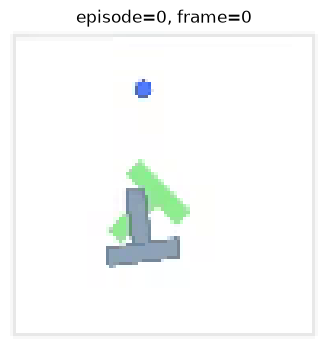

In [10]:

image = sample["observation.image"]

# PyTorch 图像是 CHW；matplotlib 需要 HWC
image_hwc = image.permute(1, 2, 0).clamp(0.0, 1.0)

plt.figure(figsize=(4, 4))
plt.imshow(image_hwc)
plt.title(
    f"episode={sample['episode_index'].item()}, "
    f"frame={sample['frame_index'].item()}"
)
plt.axis("off")
plt.show()



`permute(1, 2, 0)` 将：

```text
(C, H, W)
```

转换为：

```text
(H, W, C)
```

它只改变维度顺序，不改变像素内容。


## 10. 理解当前状态与动作

In [11]:

state_t = sample["observation.state"]
action_t = sample["action"]
delta = action_t - state_t

print("当前状态 state_t：", state_t.tolist())
print("当前动作 action_t：", action_t.tolist())
print("action_t - state_t：", delta.tolist())


当前状态 state_t： [222.0, 97.0]
当前动作 action_t： [233.0, 71.0]
action_t - state_t： [11.0, -26.0]


In [12]:
for i in range(5):

    sample=dataset[i]

    print(
        "t:",
        sample["observation.state"].numpy(),
        "action:",
        sample["action"].numpy()
    )

t: [222.  97.] action: [233.  71.]
t: [225.2524   89.31253] action: [229.  83.]
t: [227.59233  84.53438] action: [229.  86.]
t: [228.42017  84.27986] action: [230.  86.]
t: [229.04222  84.9571 ] action: [239.  89.]



在 PushT 中：

- `observation.state`：圆形推杆当前二维位置；
- `action`：推杆希望移动到的目标二维位置。

因此：

```text
action - state
```

可以粗略看作当前控制目标相对当前位置的方向与距离。

ACT 等策略模型主要学习：

```text
当前 observation
        ↓
合理的 action 或未来 action chunk
```

下一状态不是 ACT 直接预测的，而是仿真环境执行动作后产生的。


## 11. 用相邻 frame 构造一条 transition

In [13]:

current = dataset[0]
following = dataset[1]

assert current["episode_index"].item() == following["episode_index"].item()

transition = {
    "observation_t": current["observation.state"],
    "action_t": current["action"],
    "observation_t_plus_1": following["observation.state"],
    "reward_t_plus_1": current["next.reward"],
    "done_t_plus_1": current["next.done"],
    "success_t_plus_1": current["next.success"],
}

for key, value in transition.items():
    if isinstance(value, torch.Tensor):
        print(f"{key}: {value.tolist()}")
    else:
        print(f"{key}: {value}")


observation_t: [222.0, 97.0]
action_t: [233.0, 71.0]
observation_t_plus_1: [225.2523956298828, 89.31253051757812]
reward_t_plus_1: 0.19029748439788818
done_t_plus_1: False
success_t_plus_1: False



一条状态转移可以写成：

```text
observation_t
+ action_t
        ↓ 环境执行
observation_t+1
+ reward_t+1
+ done_t+1
+ success_t+1
```

LeRobot 的单帧 sample 并不直接保存 `next.observation.state`，所以需要读取相邻 frame：

```python
dataset[i + 1]["observation.state"]
```

但必须确认两帧属于同一个 episode，不能跨越 episode 边界。


In [14]:

target = current["action"]
distance_before = torch.linalg.vector_norm(target - current["observation.state"])
distance_after = torch.linalg.vector_norm(target - following["observation.state"])

print("执行前到目标的距离：", distance_before.item())
print("下一帧到目标的距离：", distance_after.item())
print("是否更接近目标：", bool(distance_after < distance_before))


执行前到目标的距离： 28.23118782043457
下一帧到目标的距离： 19.884017944335938
是否更接近目标： True


## 12. 对比 episode 中多个代表性 frame

In [15]:

selected_indices = [0, 1, len(dataset) // 2, len(dataset) - 1]

rows = []

for dataset_index in selected_indices:
    item = dataset[dataset_index]
    rows.append(
        {
            "dataset_index": dataset_index,
            "episode_index": item["episode_index"].item(),
            "frame_index": item["frame_index"].item(),
            "timestamp": item["timestamp"].item(),
            "state": item["observation.state"].tolist(),
            "action": item["action"].tolist(),
            "reward": item["next.reward"].item(),
            "done": item["next.done"].item(),
            "success": item["next.success"].item(),
        }
    )

import pandas as pd

pd.DataFrame(rows)


,dataset_index,episode_index,frame_index,timestamp,state,action,reward,done,success
0,0,0,0,0.0,"[222.0, 97.0]","[233.0, 71.0]",0.190297,False,False
1,1,0,1,0.1,"[225.2523956298828, 89.31253051757812]","[229.0, 83.0]",0.190297,False,False
2,80,0,80,8.0,"[254.119140625, 216.7681884765625]","[260.0, 191.0]",0.360246,False,False
3,160,0,160,16.0,"[158.33016967773438, 360.7481994628906]","[164.0, 355.0]",0.873257,True,False



这张表把 episode 0 中几个不同时间点放在一起，便于观察：

- `frame_index` 如何递增；
- `timestamp` 是否与 10 FPS 对应；
- `state` 与 `action` 如何变化；
- 最后一帧何时 `done=True`；
- reward 是否逐步提高。


## 13. 手动构造 ACT 的 action chunk

In [16]:

start_index = 0
chunk_size = 16

action_chunk = torch.stack(
    [
        dataset[i]["action"]
        for i in range(start_index, start_index + chunk_size)
    ],
    dim=0,
)

print("单帧 action shape：", tuple(dataset[0]["action"].shape))
print("action chunk shape：", tuple(action_chunk.shape))
print(action_chunk[:5])


单帧 action shape： (2,)
action chunk shape： (16, 2)
tensor([[233.,  71.],
        [229.,  83.],
        [229.,  86.],
        [230.,  86.],
        [239.,  89.]])



原始数据逐帧保存：

```text
action[0] shape = (2,)
action[1] shape = (2,)
...
```

把未来 16 帧动作堆叠后：

```text
action_chunk shape = (16, 2)
```

这就是 ACT 的核心训练目标形式之一：

```text
当前 observation
        ↓
未来一段 action
```

原始数据不需要专门重新采集；只要完整轨迹中有连续 observation 和 action，就可以在读取时构造动作时间窗口。


## 14. 理解 batch：多条训练样本如何一起送入模型

In [17]:

batch_indices = [0, 10, 20, 30]

image_batch = torch.stack(
    [dataset[i]["observation.image"] for i in batch_indices],
    dim=0,
)

state_batch = torch.stack(
    [dataset[i]["observation.state"] for i in batch_indices],
    dim=0,
)

action_batch = torch.stack(
    [dataset[i]["action"] for i in batch_indices],
    dim=0,
)

print("image_batch shape：", tuple(image_batch.shape))
print("state_batch shape：", tuple(state_batch.shape))
print("action_batch shape：", tuple(action_batch.shape))


image_batch shape： (4, 3, 96, 96)
state_batch shape： (4, 2)
action_batch shape： (4, 2)



单条样本：

```text
image  (3, 96, 96)
state  (2,)
action (2,)
```

四条样本组成 batch 后：

```text
image  (4, 3, 96, 96)
state  (4, 2)
action (4, 2)
```

第一维是 `batch_size`。训练时通常由 `DataLoader` 自动完成批量组织。


## 15. 查看对象有哪些属性和方法

In [18]:

# dir(...) 会列出对象可访问的属性和方法。
# 过滤掉以下划线开头的内部成员，便于初学者阅读。

metadata_members = [
    name for name in dir(metadata)
    if not name.startswith("_")
]

dataset_members = [
    name for name in dir(dataset)
    if not name.startswith("_")
]

print("LeRobotDatasetMetadata 的公开成员：")
print(metadata_members)

print("\nLeRobotDataset 的公开成员：")
print(dataset_members)


LeRobotDatasetMetadata 的公开成员：
['camera_keys', 'chunks_size', 'create', 'data_files_size_in_mb', 'data_path', 'depth_keys', 'ensure_readable', 'episodes', 'features', 'filter_episodes', 'finalize', 'fps', 'get_chunk_settings', 'get_data_file_path', 'get_task_index', 'get_video_file_path', 'has_language_columns', 'image_keys', 'info', 'latest_episode', 'names', 'repo_id', 'repo_type', 'rescale_depth_stats', 'revision', 'robot_type', 'root', 'save_episode', 'save_episode_tasks', 'shapes', 'stats', 'tasks', 'tools', 'total_episodes', 'total_frames', 'total_tasks', 'update_chunk_settings', 'update_video_info', 'url_root', 'video_files_size_in_mb', 'video_keys', 'video_path']

LeRobotDataset 的公开成员：
['absolute_to_relative_idx', 'add_frame', 'clear_episode_buffer', 'clear_image_transforms', 'create', 'delta_timestamps', 'depth_output_unit', 'episodes', 'features', 'finalize', 'fps', 'get_raw_item', 'has_pending_frames', 'hf_dataset', 'image_transforms', 'meta', 'num_episodes', 'num_frames', 'p


`dir(object)` 很适合探索一个陌生 Python 对象，但要注意：

- 列出的成员不一定都适合直接修改；
- 有些是属性，有些是方法；
- 方法通常可通过 `help(...)` 查看说明；
- 不建议依赖以下划线开头的内部成员。

例如：

```python
help(LeRobotDataset)
help(LeRobotDatasetMetadata)
```


In [20]:

# 查看类的帮助文档。输出可能较长。
help(LeRobotDatasetMetadata)


Help on class LeRobotDatasetMetadata in module lerobot.datasets.dataset_metadata:

class LeRobotDatasetMetadata(builtins.object)
 |  LeRobotDatasetMetadata(repo_id: str, root: str | pathlib.Path | None = None, revision: str | None = None, force_cache_sync: bool = False, metadata_buffer_size: int = 10, *, repo_type: Literal['dataset', 'bucket'] = 'dataset', token: str | bool | None = None)
 |
 |  Metadata container for a LeRobot dataset.
 |
 |  Manages the ``info.json``, ``stats.json``, ``tasks.parquet``, and
 |  ``episodes/`` parquet files that describe a dataset's structure, content,
 |  and statistics.
 |
 |  Methods defined here:
 |
 |  __del__(self)
 |      Safety net: flush and close parquet writer on garbage collection.
 |
 |  __init__(self, repo_id: str, root: str | pathlib.Path | None = None, revision: str | None = None, force_cache_sync: bool = False, metadata_buffer_size: int = 10, *, repo_type: Literal['dataset', 'bucket'] = 'dataset', token: str | bool | None = None)
 |    


## 16. 本 Notebook 完成后应掌握的概念

```text
LeRobotDatasetMetadata
    数据集结构和说明

LeRobotDataset
    实际读取数据的 PyTorch Dataset

episode
    一次完整任务回合

frame
    某个采样时刻的一条记录

sample = dataset[i]
    当前筛选数据集中的第 i 条 frame

transition
    observation_t + action_t → observation_t+1

action chunk
    一段连续未来动作，常用于 ACT 和 Diffusion Policy
```

下一步建议继续学习：

1. `metadata.stats` 与归一化；
2. LeRobot 的时间窗口读取；
3. `DataLoader`；
4. ACT 的输入、输出和 loss；
5. 小规模训练冒烟测试。
